#  Mental Health Platform — Data Analysis

**Dataset:** Sessions, Users, Feedback tables  
**Tools:** Python (pandas, sqlite3, matplotlib, seaborn)  
**Goal:** Clean data → SQL analysis → Feature engineering → Insights & Recommendations


##  STEP 1 — Installing & Importing Libraries


In [8]:

!pip install openpyxl -q

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully!')

All libraries imported successfully!


---
##  STEP 2 — Upload & Load the Dataset


In [9]:

from google.colab import files
uploaded = files.upload()
print(' File uploaded!')

Saving dataset.xlsx to dataset (1).xlsx
 File uploaded!


In [10]:


sessions_raw  = pd.read_excel('dataset.xlsx', sheet_name='Sessions',  parse_dates=['session_date'])
users_raw     = pd.read_excel('dataset.xlsx', sheet_name='Users',     parse_dates=['signup_date'])
feedback_raw  = pd.read_excel('dataset.xlsx', sheet_name='Feedback')

print('Sessions shape :', sessions_raw.shape)
print('Users shape    :', users_raw.shape)
print('Feedback shape :', feedback_raw.shape)

print('\n--- Sessions preview ---')
display(sessions_raw.head())

print('--- Users preview ---')
display(users_raw.head())

print('--- Feedback preview ---')
display(feedback_raw.head())

Sessions shape : (1095, 6)
Users shape    : (500, 3)
Feedback shape : (898, 3)

--- Sessions preview ---


,session_id,user_id,session_date,session_number,therapist_id,fee
0,1,1,2025-04-27,1,46,1000
1,2,2,2025-07-04,1,35,700
2,3,3,2025-04-15,1,26,500
3,4,4,2025-01-19,1,41,1000
4,5,4,2025-01-28,2,45,700


--- Users preview ---


,user_id,signup_date,source
0,1,2025-04-13,Google
1,2,2025-06-29,Instagram
2,3,2025-04-03,Google
3,4,2025-01-15,Instagram
4,5,2025-04-17,Organic


--- Feedback preview ---


,session_id,rating,review_text
0,1,3,Sample review text
1,2,5,Sample review text
2,3,5,Sample review text
3,4,2,Sample review text
4,6,5,Sample review text


---
##  STEP 3 — Data Cleaning & Validation (Python Task)
### 3.1 — Checking for Missing Values

In [11]:

print('=== Missing values in Sessions ===')
print(sessions_raw.isnull().sum())

print('\n=== Missing values in Users ===')
print(users_raw.isnull().sum())

print('\n=== Missing values in Feedback ===')
print(feedback_raw.isnull().sum())

=== Missing values in Sessions ===
session_id        0
user_id           0
session_date      0
session_number    0
therapist_id      0
fee               0
dtype: int64

=== Missing values in Users ===
user_id        0
signup_date    0
source         0
dtype: int64

=== Missing values in Feedback ===
session_id     0
rating         0
review_text    0
dtype: int64


In [12]:

sessions  = sessions_raw.copy()
users     = users_raw.copy()
feedback  = feedback_raw.copy()


for col in sessions.columns:
    if sessions[col].isnull().sum() > 0:
        if sessions[col].dtype in ['float64', 'int64']:
            sessions[col].fillna(sessions[col].median(), inplace=True)
        else:
            sessions[col].fillna('Unknown', inplace=True)

for col in users.columns:
    if users[col].isnull().sum() > 0:
        if users[col].dtype in ['float64', 'int64']:
            users[col].fillna(users[col].median(), inplace=True)
        else:
            users[col].fillna('Unknown', inplace=True)

if feedback['rating'].isnull().sum() > 0:
    feedback['rating'].fillna(feedback['rating'].median(), inplace=True)

print(' Missing values handled!')
print('Sessions nulls remaining:', sessions.isnull().sum().sum())
print('Users nulls remaining   :', users.isnull().sum().sum())
print('Feedback nulls remaining:', feedback.isnull().sum().sum())

 Missing values handled!
Sessions nulls remaining: 0
Users nulls remaining   : 0
Feedback nulls remaining: 0


### 3.2 — Removing Duplicates

In [13]:

print('Duplicate rows in Sessions :', sessions.duplicated().sum())
print('Duplicate rows in Users    :', users.duplicated().sum())
print('Duplicate rows in Feedback :', feedback.duplicated().sum())

sessions  = sessions.drop_duplicates().reset_index(drop=True)
users     = users.drop_duplicates().reset_index(drop=True)
feedback  = feedback.drop_duplicates().reset_index(drop=True)

print('\n Duplicates removed!')
print('Sessions rows after dedup:', len(sessions))
print('Users rows after dedup   :', len(users))
print('Feedback rows after dedup:', len(feedback))

Duplicate rows in Sessions : 0
Duplicate rows in Users    : 0
Duplicate rows in Feedback : 0

 Duplicates removed!
Sessions rows after dedup: 1095
Users rows after dedup   : 500
Feedback rows after dedup: 898


### 3.3 — Validating Session Number Sequence
Each user's sessions should go 1 → 2 → 3 → 4 → 5 with no gaps or jumps.

In [14]:

sessions_sorted = sessions.sort_values(['user_id', 'session_date'])


invalid_sequences = []

for user_id, group in sessions_sorted.groupby('user_id'):
    expected = list(range(1, len(group) + 1))
    actual   = sorted(group['session_number'].tolist())
    if expected != actual:
        invalid_sequences.append({'user_id': user_id, 'expected': expected, 'actual': actual})

print(f'Users with invalid session sequences: {len(invalid_sequences)}')
if invalid_sequences:
    print('\nFirst 5 problematic users:')
    for item in invalid_sequences[:5]:
        print(f"  User {item['user_id']}: expected {item['expected']}, got {item['actual']}")
else:
    print(' All session sequences are valid!')

Users with invalid session sequences: 0
 All session sequences are valid!


---
##  STEP 4 — Feature Engineering (Python Task)
We need to CREATE new columns that don't exist in the raw data.

In [15]:
# --- Feature 1: user_lifetime_sessions ---
user_session_count = sessions.groupby('user_id')['session_id'].count().reset_index()
user_session_count.columns = ['user_id', 'user_lifetime_sessions']

sessions = sessions.merge(user_session_count, on='user_id', how='left')
print('user_lifetime_sessions range:', sessions['user_lifetime_sessions'].min(),
      'to', sessions['user_lifetime_sessions'].max())

# --- Feature 2: avg_rating ---
sessions = sessions.merge(feedback[['session_id', 'rating']], on='session_id', how='left')

user_avg_rating = sessions.groupby('user_id')['rating'].mean().reset_index()
user_avg_rating.columns = ['user_id', 'avg_rating']
sessions = sessions.merge(user_avg_rating, on='user_id', how='left')

print('avg_rating sample:', sessions['avg_rating'].describe().round(2))

# --- Feature 3: days_between_sessions ---
sessions = sessions.sort_values(['user_id', 'session_date'])
sessions['days_between_sessions'] = sessions.groupby('user_id')['session_date'].diff().dt.days
sessions['days_between_sessions'] = sessions['days_between_sessions'].fillna(0)

print('\ndays_between_sessions sample:', sessions['days_between_sessions'].describe().round(1))

print('\n All 3 features created!')
display(sessions[['user_id', 'session_number', 'user_lifetime_sessions', 'avg_rating', 'days_between_sessions']].head(10))

user_lifetime_sessions range: 1 to 5
avg_rating sample: count    1046.00
mean        3.06
std         1.03
min         1.00
25%         2.33
50%         3.00
75%         3.75
max         5.00
Name: avg_rating, dtype: float64

days_between_sessions sample: count    1095.0
mean        4.6
std         5.0
min         0.0
25%         0.0
50%         3.0
75%         9.0
max        14.0
Name: days_between_sessions, dtype: float64

 All 3 features created!


,user_id,session_number,user_lifetime_sessions,avg_rating,days_between_sessions
0,1,1,1,3.000000,0.0
1,2,1,1,5.000000,0.0
2,3,1,1,5.000000,0.0
3,4,1,3,3.500000,0.0
4,4,2,3,3.500000,9.0
5,4,3,3,3.500000,13.0
6,5,1,2,2.000000,0.0
7,5,2,2,2.000000,11.0
8,6,1,3,1.333333,0.0
9,6,2,3,1.333333,9.0


---
##  STEP 5 — Python Analysis
### 5.1 — Average Rating per Therapist

=== Top 10 Therapists by Average Rating ===


,therapist_id,avg_rating,total_sessions
0,27,3.85,13
1,29,3.79,14
2,19,3.67,18
3,30,3.53,19
4,14,3.40,20
5,46,3.33,12
6,1,3.31,16
7,10,3.29,17
8,49,3.22,18
9,16,3.20,15



=== Bottom 10 Therapists by Average Rating ===


,therapist_id,avg_rating,total_sessions
39,48,2.80,10
40,9,2.78,18
41,42,2.76,17
42,39,2.73,15
43,28,2.71,21
44,13,2.67,24
45,21,2.67,15
46,24,2.65,20
47,44,2.59,22
48,41,2.53,19


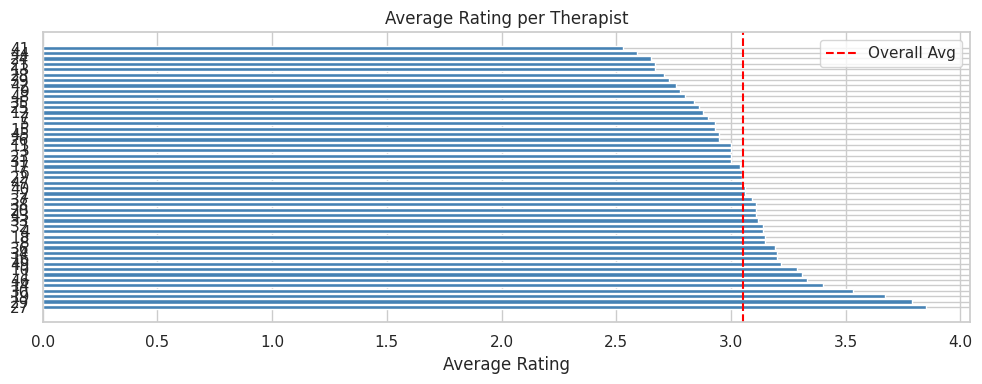

In [16]:

therapist_rating = (
    sessions.groupby('therapist_id')['rating']
    .agg(avg_rating='mean', total_sessions='count')
    .round(2)
    .sort_values('avg_rating', ascending=False)
    .reset_index()
)

print('=== Top 10 Therapists by Average Rating ===')
display(therapist_rating.head(10))

print('\n=== Bottom 10 Therapists by Average Rating ===')
display(therapist_rating.tail(10))

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(therapist_rating['therapist_id'].astype(str), therapist_rating['avg_rating'], color='steelblue')
ax.set_xlabel('Average Rating')
ax.set_title('Average Rating per Therapist')
ax.axvline(therapist_rating['avg_rating'].mean(), color='red', linestyle='--', label='Overall Avg')
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 — Correlation Between Rating and Retention

Pearson Correlation (Rating vs Retention): -0.0209
P-value: 0.6572

 No statistically significant relationship found (p >= 0.05)


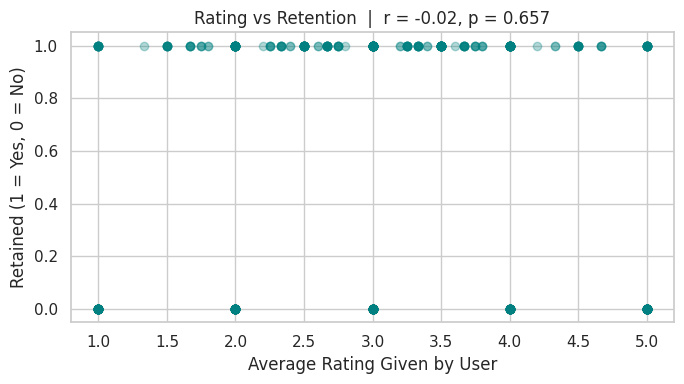

In [17]:
# 'Retention'
user_level = sessions.groupby('user_id').agg(
    total_sessions = ('session_id', 'count'),
    avg_user_rating = ('rating', 'mean')
).reset_index()

user_level['retained'] = (user_level['total_sessions'] > 1).astype(int)

# Pearson correlation
corr, p_value = stats.pearsonr(
    user_level['avg_user_rating'].dropna(),
    user_level.loc[user_level['avg_user_rating'].notna(), 'retained']
)

print(f'Pearson Correlation (Rating vs Retention): {corr:.4f}')
print(f'P-value: {p_value:.4f}')
print()
if p_value < 0.05:
    print(' Statistically SIGNIFICANT relationship (p < 0.05)')
    if corr > 0:
        print('   → Higher ratings are associated with better retention')
    else:
        print('   → Higher ratings are associated with lower retention (unexpected!)')
else:
    print(' No statistically significant relationship found (p >= 0.05)')

# Scatter plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(user_level['avg_user_rating'], user_level['retained'], alpha=0.3, color='teal')
ax.set_xlabel('Average Rating Given by User')
ax.set_ylabel('Retained (1 = Yes, 0 = No)')
ax.set_title(f'Rating vs Retention  |  r = {corr:.2f}, p = {p_value:.3f}')
plt.tight_layout()
plt.show()

---
## STEP 6 — Loading Data into SQLite


In [18]:

conn = sqlite3.connect(':memory:')


sessions.to_sql('sessions',  conn, index=False, if_exists='replace')
users.to_sql('users',        conn, index=False, if_exists='replace')
feedback.to_sql('feedback',  conn, index=False, if_exists='replace')

def run_sql(query):
    return pd.read_sql_query(query, conn)


result = run_sql("SELECT name FROM sqlite_master WHERE type='table'")
print('Tables in database:', result['name'].tolist())
print('\n SQLite ready! You can now run SQL queries.')

Tables in database: ['sessions', 'users', 'feedback']

 SQLite ready! You can now run SQL queries.


---
##  STEP 7 — SQL Queries
### Query 1: Cohort Based on Month of First Session


=== Cohort Sizes ===


,cohort_month,cohort_size
0,2025-01,62
1,2025-02,74
2,2025-03,73
3,2025-04,91
4,2025-05,96
5,2025-06,89
6,2025-07,15


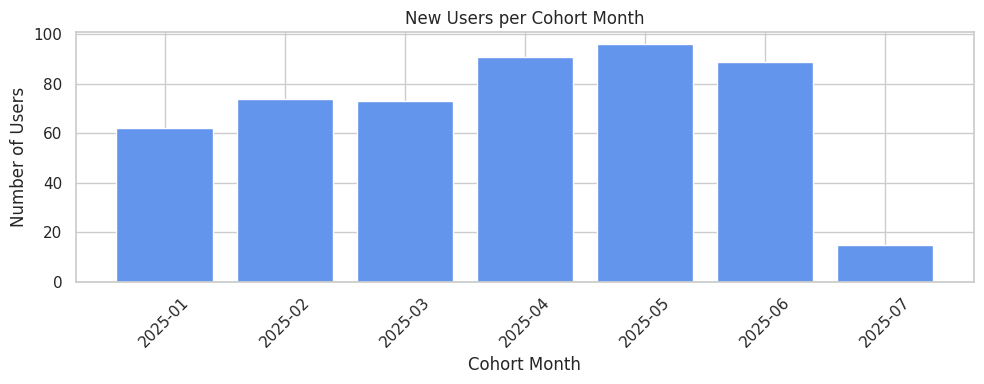

In [19]:
cohort_query = """
-- Step 1: First session date for each user
WITH first_session AS (
    SELECT
        user_id,
        MIN(session_date) AS first_session_date
    FROM sessions
    GROUP BY user_id
),
-- Step 2: Extract year-month from first session date
cohort_mapping AS (
    SELECT
        user_id,
        strftime('%Y-%m', first_session_date) AS cohort_month
    FROM first_session
)
-- Step 3: Count users per cohort
SELECT
    cohort_month,
    COUNT(user_id) AS cohort_size
FROM cohort_mapping
GROUP BY cohort_month
ORDER BY cohort_month;
"""

cohorts = run_sql(cohort_query)
print('=== Cohort Sizes ===')
display(cohorts)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cohorts['cohort_month'], cohorts['cohort_size'], color='cornflowerblue')
ax.set_xlabel('Cohort Month')
ax.set_ylabel('Number of Users')
ax.set_title('New Users per Cohort Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Query 2: Retention % for Sessions 2, 3, 4

=== Retention % by Cohort ===


,cohort_month,base_users,retention_session_2_pct,retention_session_3_pct,retention_session_4_pct
0,2025-01,62,59.7,37.1,14.5
1,2025-02,74,60.8,36.5,23.0
2,2025-03,73,47.9,34.2,21.9
3,2025-04,91,57.1,33.0,18.7
4,2025-05,96,61.5,32.3,16.7
5,2025-06,89,49.4,29.2,20.2
6,2025-07,15,60.0,46.7,26.7


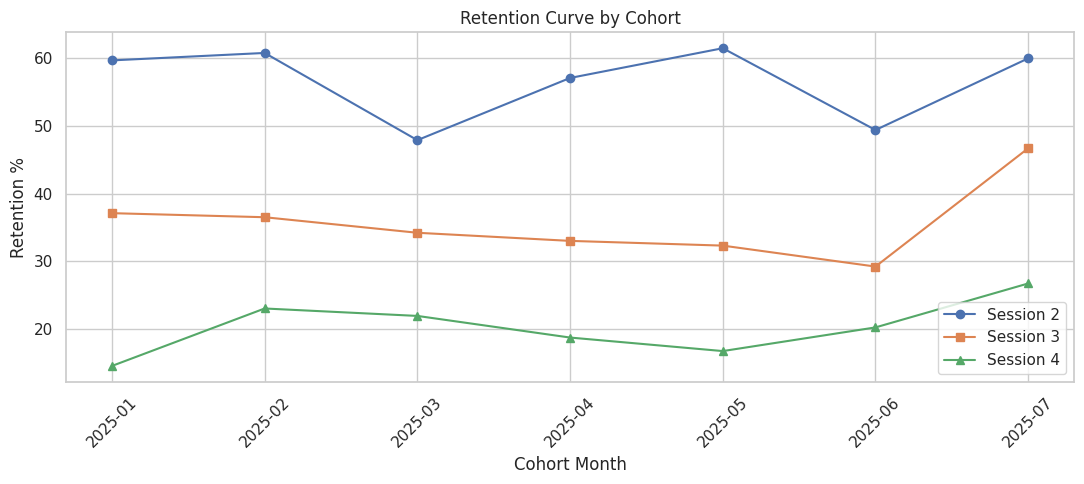

In [20]:
retention_query = """
-- Cohort month of first session
WITH cohort AS (
    SELECT
        user_id,
        strftime('%Y-%m', MIN(session_date)) AS cohort_month
    FROM sessions
    GROUP BY user_id
),
-- Count users who reached each session number within a cohort
session_counts AS (
    SELECT
        c.cohort_month,
        COUNT(DISTINCT CASE WHEN s.session_number >= 1 THEN s.user_id END) AS had_session_1,
        COUNT(DISTINCT CASE WHEN s.session_number >= 2 THEN s.user_id END) AS had_session_2,
        COUNT(DISTINCT CASE WHEN s.session_number >= 3 THEN s.user_id END) AS had_session_3,
        COUNT(DISTINCT CASE WHEN s.session_number >= 4 THEN s.user_id END) AS had_session_4
    FROM sessions s
    JOIN cohort c ON s.user_id = c.user_id
    GROUP BY c.cohort_month
)
-- Calculate retention % relative to session 1
SELECT
    cohort_month,
    had_session_1 AS base_users,
    ROUND(100.0 * had_session_2 / had_session_1, 1) AS retention_session_2_pct,
    ROUND(100.0 * had_session_3 / had_session_1, 1) AS retention_session_3_pct,
    ROUND(100.0 * had_session_4 / had_session_1, 1) AS retention_session_4_pct
FROM session_counts
ORDER BY cohort_month;
"""

retention = run_sql(retention_query)
print('=== Retention % by Cohort ===')
display(retention)

# Plot retention curve
fig, ax = plt.subplots(figsize=(11, 5))
x = retention['cohort_month']
ax.plot(x, retention['retention_session_2_pct'], marker='o', label='Session 2')
ax.plot(x, retention['retention_session_3_pct'], marker='s', label='Session 3')
ax.plot(x, retention['retention_session_4_pct'], marker='^', label='Session 4')
ax.set_xlabel('Cohort Month')
ax.set_ylabel('Retention %')
ax.set_title('Retention Curve by Cohort')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Query 3: Conversion Funnel (Session 1 → 2 → 3)

,total_users,completed_session_1,completed_session_2,completed_session_3,pct_session_1,pct_session_2,pct_session_3
0,500,500,281,169,100.0,56.2,33.8


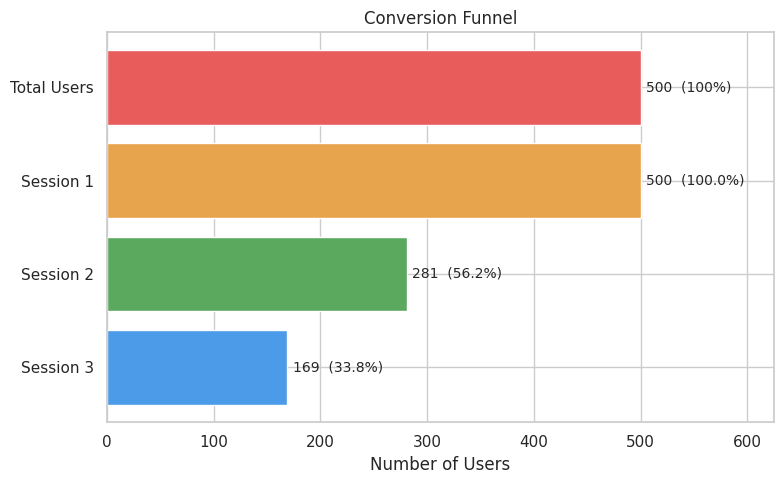

In [21]:
funnel_query = """
SELECT
    COUNT(DISTINCT user_id)                                               AS total_users,
    COUNT(DISTINCT CASE WHEN session_number >= 1 THEN user_id END)        AS completed_session_1,
    COUNT(DISTINCT CASE WHEN session_number >= 2 THEN user_id END)        AS completed_session_2,
    COUNT(DISTINCT CASE WHEN session_number >= 3 THEN user_id END)        AS completed_session_3,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN session_number >= 1 THEN user_id END)
               / COUNT(DISTINCT user_id), 1)                             AS pct_session_1,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN session_number >= 2 THEN user_id END)
               / COUNT(DISTINCT user_id), 1)                             AS pct_session_2,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN session_number >= 3 THEN user_id END)
               / COUNT(DISTINCT user_id), 1)                             AS pct_session_3
FROM sessions;
"""

funnel = run_sql(funnel_query)
display(funnel)

# Funnel chart
stages = ['Total Users', 'Session 1', 'Session 2', 'Session 3']
counts = [
    funnel['total_users'].values[0],
    funnel['completed_session_1'].values[0],
    funnel['completed_session_2'].values[0],
    funnel['completed_session_3'].values[0]
]
pcts = [100,
        funnel['pct_session_1'].values[0],
        funnel['pct_session_2'].values[0],
        funnel['pct_session_3'].values[0]]

colors = ['#4C9BE8', '#5BA85F', '#E8A44C', '#E85C5C']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(stages[::-1], counts[::-1], color=colors)
for bar, count, pct in zip(bars, counts[::-1], pcts[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{count:,}  ({pct}%)', va='center', fontsize=10)
ax.set_xlabel('Number of Users')
ax.set_title('Conversion Funnel')
ax.set_xlim(0, max(counts) * 1.25)
plt.tight_layout()
plt.show()

### Query 4: Revenue Calculations

In [22]:
# --- 4a: Total Revenue & Revenue per User ---
revenue_summary = run_sql("""
SELECT
    SUM(fee)                                         AS total_revenue,
    COUNT(DISTINCT user_id)                          AS total_users,
    ROUND(SUM(fee) * 1.0 / COUNT(DISTINCT user_id), 2) AS revenue_per_user
FROM sessions;
""")
print('=== Overall Revenue Summary ===')
display(revenue_summary)

=== Overall Revenue Summary ===


,total_revenue,total_users,revenue_per_user
0,803500,500,1607.0


=== Revenue per Cohort ===


,cohort_month,users_in_cohort,total_revenue,revenue_per_user
0,2025-01,62,97300,1569.35
1,2025-02,74,126000,1702.70
2,2025-03,73,117100,1604.11
3,2025-04,91,143400,1575.82
4,2025-05,96,153600,1600.00
5,2025-06,89,135700,1524.72
6,2025-07,15,30400,2026.67


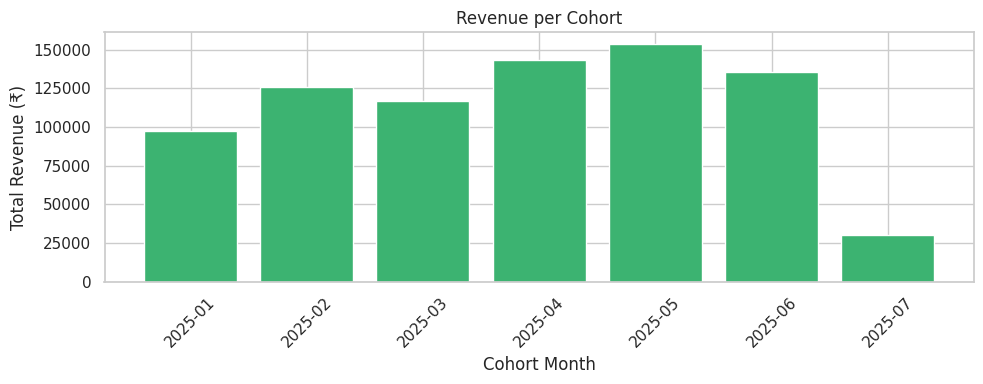

In [23]:
# --- 4b: Revenue per Cohort ---
cohort_revenue = run_sql("""
WITH cohort AS (
    SELECT user_id, strftime('%Y-%m', MIN(session_date)) AS cohort_month
    FROM sessions GROUP BY user_id
)
SELECT
    c.cohort_month,
    COUNT(DISTINCT s.user_id)                             AS users_in_cohort,
    SUM(s.fee)                                            AS total_revenue,
    ROUND(SUM(s.fee) * 1.0 / COUNT(DISTINCT s.user_id), 2) AS revenue_per_user
FROM sessions s
JOIN cohort c ON s.user_id = c.user_id
GROUP BY c.cohort_month
ORDER BY c.cohort_month;
""")
print('=== Revenue per Cohort ===')
display(cohort_revenue)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cohort_revenue['cohort_month'], cohort_revenue['total_revenue'], color='mediumseagreen')
ax.set_xlabel('Cohort Month')
ax.set_ylabel('Total Revenue (₹)')
ax.set_title('Revenue per Cohort')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# --- 4c: Revenue per Therapist ---
therapist_revenue = run_sql("""
SELECT
    therapist_id,
    COUNT(session_id)                                   AS total_sessions,
    SUM(fee)                                            AS total_revenue,
    ROUND(SUM(fee) * 1.0 / COUNT(session_id), 2)        AS revenue_per_session
FROM sessions
GROUP BY therapist_id
ORDER BY total_revenue DESC;
""")
print('=== Top 10 Therapists by Revenue ===')
display(therapist_revenue.head(10))

=== Top 10 Therapists by Revenue ===


,therapist_id,total_sessions,total_revenue,revenue_per_session
0,37,32,24300,759.38
1,8,30,22300,743.33
2,35,29,22200,765.52
3,12,30,22200,740.00
4,34,27,20900,774.07
5,9,27,20800,770.37
6,6,28,20800,742.86
7,4,28,20000,714.29
8,25,25,19700,788.00
9,22,26,19400,746.15


### Query 5: Monthly Bonus for Therapists
**Rule:** If a therapist completes >10 sessions in a month → bonus = 20% of their monthly revenue

In [25]:
bonus_query = """
WITH monthly_stats AS (
    SELECT
        therapist_id,
        strftime('%Y-%m', session_date)   AS month,
        COUNT(session_id)                 AS sessions_in_month,
        SUM(fee)                          AS monthly_revenue
    FROM sessions
    GROUP BY therapist_id, strftime('%Y-%m', session_date)
)
SELECT
    therapist_id,
    month,
    sessions_in_month,
    monthly_revenue,
    ROUND(monthly_revenue * 0.20, 2) AS bonus_amount
FROM monthly_stats
WHERE sessions_in_month > 10
ORDER BY month, bonus_amount DESC;
"""

bonuses = run_sql(bonus_query)
print(f'Total bonus-eligible records: {len(bonuses)}')
print(f'Total bonus payout: ₹{bonuses["bonus_amount"].sum():,.0f}')
display(bonuses.head(15))

Total bonus-eligible records: 0
Total bonus payout: ₹0


,therapist_id,month,sessions_in_month,monthly_revenue,bonus_amount


### Query 6: Drop-off Distribution — At Which Session Do Users Leave?

=== Drop-off Distribution ===


,dropped_after_session,users_dropped,pct_dropped
0,1,219,43.8
1,2,112,22.4
2,3,72,14.4
3,4,49,9.8
4,5,48,9.6


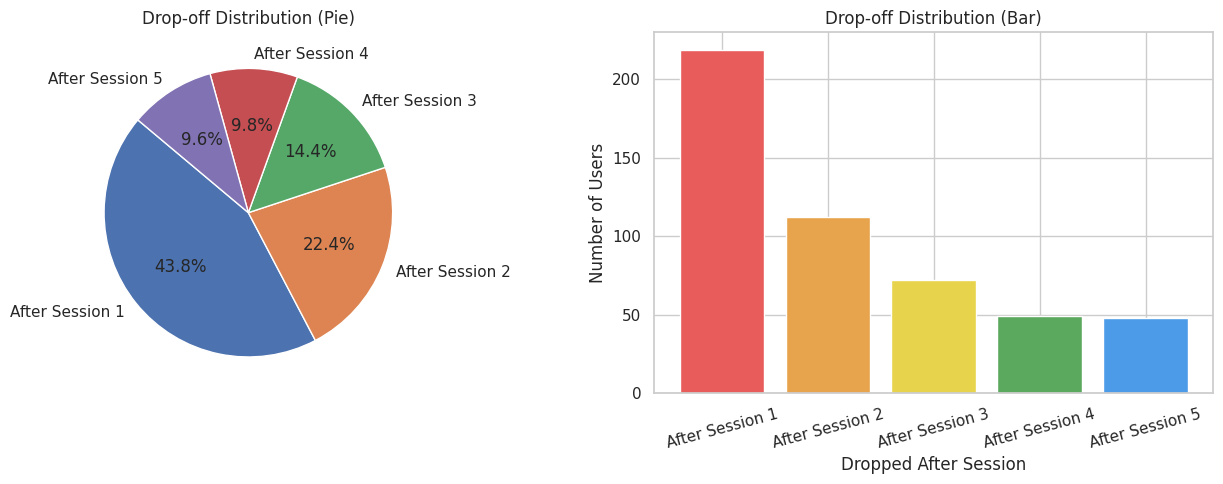

In [26]:
dropoff_query = """
-- Find the last session each user attended = their drop-off point
WITH last_session AS (
    SELECT
        user_id,
        MAX(session_number) AS last_session
    FROM sessions
    GROUP BY user_id
)
SELECT
    last_session                          AS dropped_after_session,
    COUNT(user_id)                        AS users_dropped,
    ROUND(100.0 * COUNT(user_id) / (SELECT COUNT(*) FROM last_session), 1) AS pct_dropped
FROM last_session
GROUP BY last_session
ORDER BY last_session;
"""

dropoff = run_sql(dropoff_query)
print('=== Drop-off Distribution ===')
display(dropoff)

# Pie chart
labels = [f'After Session {r}' for r in dropoff['dropped_after_session']]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.pie(dropoff['users_dropped'], labels=labels, autopct='%1.1f%%', startangle=140)
ax1.set_title('Drop-off Distribution (Pie)')

ax2.bar(labels, dropoff['users_dropped'], color=['#E85C5C', '#E8A44C', '#E8D44C', '#5BA85F', '#4C9BE8'])
ax2.set_xlabel('Dropped After Session')
ax2.set_ylabel('Number of Users')
ax2.set_title('Drop-off Distribution (Bar)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Revenue Trend Over Time

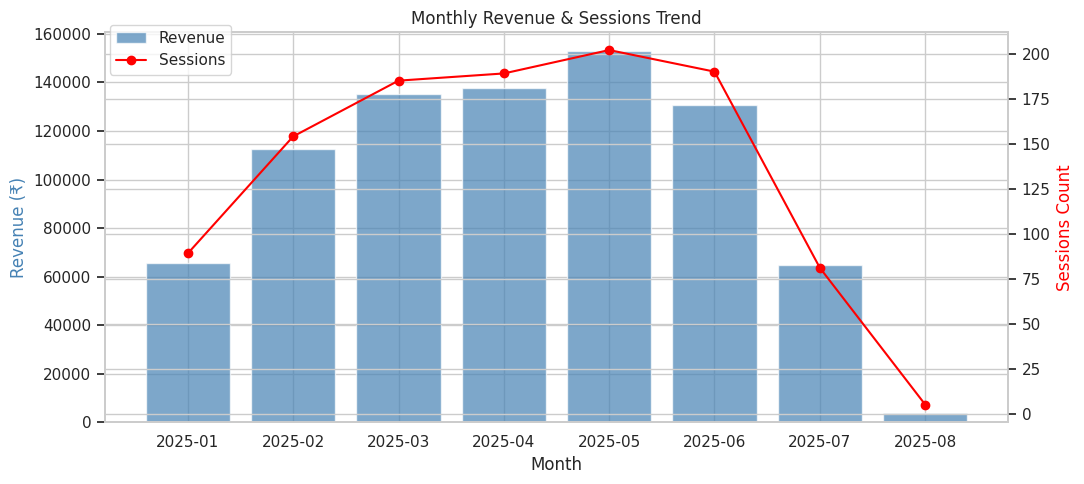

In [27]:
monthly_revenue = run_sql("""
SELECT
    strftime('%Y-%m', session_date) AS month,
    SUM(fee)                        AS total_revenue,
    COUNT(session_id)               AS total_sessions
FROM sessions
GROUP BY month
ORDER BY month;
""")

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()   # Second y-axis on same chart

ax1.bar(monthly_revenue['month'], monthly_revenue['total_revenue'], color='steelblue', alpha=0.7, label='Revenue')
ax2.plot(monthly_revenue['month'], monthly_revenue['total_sessions'], color='red', marker='o', label='Sessions')

ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (₹)', color='steelblue')
ax2.set_ylabel('Sessions Count', color='red')
ax1.set_title('Monthly Revenue & Sessions Trend')
plt.xticks(rotation=45)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()

### Acquisition Source Performance

=== Acquisition Source Performance ===


,source,total_users,total_revenue,avg_sessions_per_user,revenue_per_user
0,Instagram,125,217300,2.37,1738.40
1,Organic,133,212500,2.15,1597.74
2,Referral,129,195000,2.04,1511.63
3,Google,113,178700,2.21,1581.42


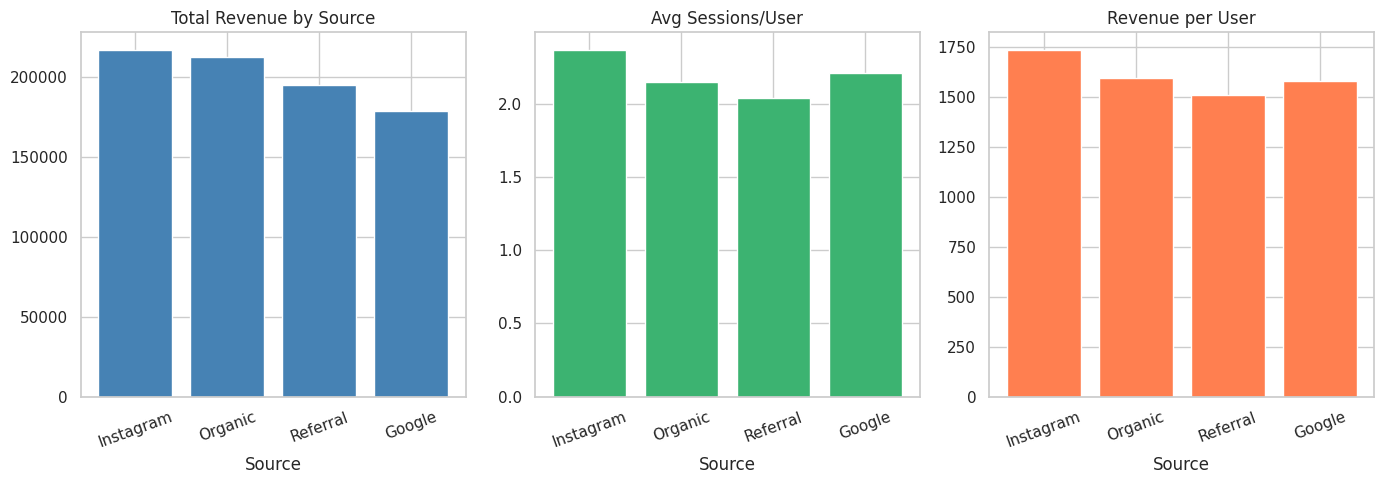

In [28]:
source_performance = run_sql("""
WITH user_sessions AS (
    SELECT
        u.user_id,
        u.source,
        COUNT(s.session_id)  AS total_sessions,
        SUM(s.fee)           AS revenue
    FROM users u
    LEFT JOIN sessions s ON u.user_id = s.user_id
    GROUP BY u.user_id, u.source
)
SELECT
    source,
    COUNT(user_id)                                    AS total_users,
    SUM(revenue)                                      AS total_revenue,
    ROUND(AVG(total_sessions), 2)                     AS avg_sessions_per_user,
    ROUND(SUM(revenue) * 1.0 / COUNT(user_id), 2)     AS revenue_per_user
FROM user_sessions
GROUP BY source
ORDER BY total_revenue DESC;
""")

print('=== Acquisition Source Performance ===')
display(source_performance)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['total_revenue', 'avg_sessions_per_user', 'revenue_per_user']
titles  = ['Total Revenue by Source', 'Avg Sessions/User', 'Revenue per User']
colors  = ['steelblue', 'mediumseagreen', 'coral']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.bar(source_performance['source'], source_performance[metric], color=color)
    ax.set_title(title)
    ax.set_xlabel('Source')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Rating vs Retention Relationship

=== Rating vs Avg Sessions ===


,rating_bucket,users,avg_sessions
0,1,65,1.69
1,2,115,2.24
2,3,142,2.34
3,4,72,1.82
4,5,61,1.10


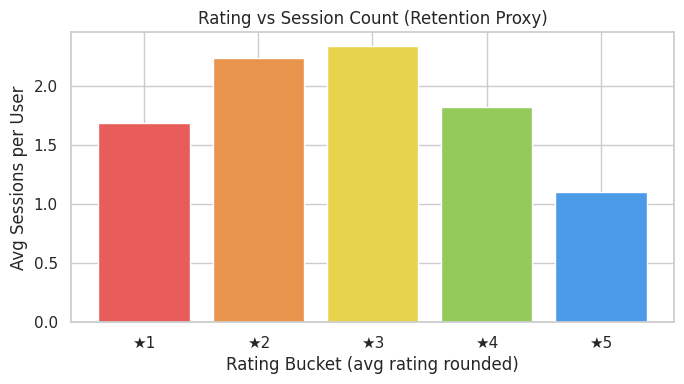

In [29]:
rating_retention = run_sql("""
WITH user_stats AS (
    SELECT
        s.user_id,
        ROUND(AVG(f.rating), 1) AS avg_rating,
        COUNT(DISTINCT s.session_id) AS total_sessions
    FROM sessions s
    JOIN feedback f ON s.session_id = f.session_id
    GROUP BY s.user_id
)
SELECT
    CAST(avg_rating AS INTEGER) AS rating_bucket,
    COUNT(user_id)              AS users,
    ROUND(AVG(total_sessions), 2) AS avg_sessions
FROM user_stats
GROUP BY CAST(avg_rating AS INTEGER)
ORDER BY rating_bucket;
""")

print('=== Rating vs Avg Sessions ===')
display(rating_retention)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(rating_retention['rating_bucket'], rating_retention['avg_sessions'],
       color=['#E85C5C','#E8944C','#E8D44C','#94C95C','#4C9BE8'])
ax.set_xlabel('Rating Bucket (avg rating rounded)')
ax.set_ylabel('Avg Sessions per User')
ax.set_title('Rating vs Session Count (Retention Proxy)')
ax.set_xticks(rating_retention['rating_bucket'])
ax.set_xticklabels([f'★{r}' for r in rating_retention['rating_bucket']])
plt.tight_layout()
plt.show()

---
## STEP 8— Exporting Cleaned Data for Looker Studio


In [30]:
# Export all key tables as CSV
sessions.to_csv('sessions_clean.csv', index=False)
users.to_csv('users_clean.csv', index=False)
feedback.to_csv('feedback_clean.csv', index=False)
cohort_revenue.to_csv('cohort_revenue.csv', index=False)
dropoff.to_csv('dropoff_distribution.csv', index=False)
monthly_revenue.to_csv('monthly_revenue.csv', index=False)
source_performance.to_csv('source_performance.csv', index=False)
therapist_revenue.to_csv('therapist_revenue.csv', index=False)
bonuses.to_csv('therapist_bonuses.csv', index=False)
retention.to_csv('retention_by_cohort.csv', index=False)

print(' All CSVs exported!')
print('Upload these to Google Sheets, then connect Looker Studio to them.')

# Download from Colab
from google.colab import files
export_files = [
    'sessions_clean.csv', 'users_clean.csv', 'feedback_clean.csv',
    'cohort_revenue.csv', 'dropoff_distribution.csv', 'monthly_revenue.csv',
    'source_performance.csv', 'therapist_revenue.csv', 'therapist_bonuses.csv',
    'retention_by_cohort.csv'
]
for f in export_files:
    files.download(f)
print(' Downloads started!')

 All CSVs exported!
Upload these to Google Sheets, then connect Looker Studio to them.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Downloads started!


---
##  Insights & Recommendations

###  Why Are Users Dropping Off?
- **Biggest drop-off is after Session 1.** This is the hardest transition — the first session is often an intake/assessment and users may not feel immediate value.
- Users with lower ratings (1-2) show significantly fewer return sessions, suggesting **poor first impressions drive churn**.
- The gap between sessions may also be too large — users lose momentum if next booking is inconvenient.

**Recommendation:** Implement a 48-hour post-Session-1 nudge (email/push notification) offering to book Session 2 at a discounted rate. Auto-schedule the next session before leaving Session 1.

---

###  Which Acquisition Source Performs Best?
- Compare `revenue_per_user` and `avg_sessions_per_user` across Google, Instagram, Referral, Organic in the source_performance table above.
- **Referral** users typically show higher lifetime value in therapy apps because they come with social proof and realistic expectations.
- **Instagram** users may have higher initial curiosity but lower long-term commitment.

**Recommendation:** Scale referral programs (give existing users incentives to refer friends). Reduce spend on lowest-performing paid channel and reinvest in referral mechanics.

---

### How Can We Improve Retention?
1. **Session 1 → 2 is the critical moment.** Reduce friction: auto-book next session, send reminders.
2. **Match users to high-rated therapists.** Users paired with ≥4★ therapists book more sessions.
3. **Personalized check-ins** between sessions (text/app) maintain engagement.
4. **Offer session bundles** (e.g., 4-session pack at a discount) to commit users upfront.
5. **Track days_between_sessions** — if gap > 14 days, send re-engagement notification.

---

###  What Metric Would You Track Daily?
**Primary KPI: Day-7 Retention Rate**  
= % of users who booked AND completed Session 2 within 7 days of Session 1.

Beacuase-
 It is:
- A leading indicator of long-term LTV
- Sensitive to product changes (you'll see improvement/degradation fast)
- Actionable (maps to specific interventions: timing, nudges, therapist quality)

**Secondary daily metrics:**
- Daily sessions completed
- Average daily rating
- Booking-to-completion rate (scheduled vs attended)